In [14]:
from galpy.potential import AnySphericalPotential, NFWPotential
import numpy as np
import matplotlib.pyplot as plt

def truncatedNFWdensity(r, rho0, a, rcutoff):
    return (rho0 / (
        (r / a) *
        (1 + r/a)**2 *
        np.exp(r/rcutoff)#np.cosh(r/rcutoff)
        )
    )

In [15]:
from functools import partial
# from astropy import units as u
rho0 = 1.0
a = 1.0
rcutoff = 2.0
truncNFWdens = partial(truncatedNFWdensity, rho0=1.0, a=1.0, rcutoff=rcutoff)

truncNFWpot = AnySphericalPotential(dens=truncNFWdens)
amp = rho0 * 4 * np.pi * a**3
nfwpot = NFWPotential(amp = amp, a = a)

truncNFWpot.turn_physical_on(ro=8.0, vo=220.0)
nfwpot.turn_physical_on(ro=8.0, vo=220.0)

/tmp/ipykernel_2752212/1279322492.py:9: RuntimeWarning: overflow encountered in exp
  np.exp(r/rcutoff)#np.cosh(r/rcutoff)



In [16]:
import astropy.units as u
rlist = np.logspace(-2, 2, 1000) * u.kpc

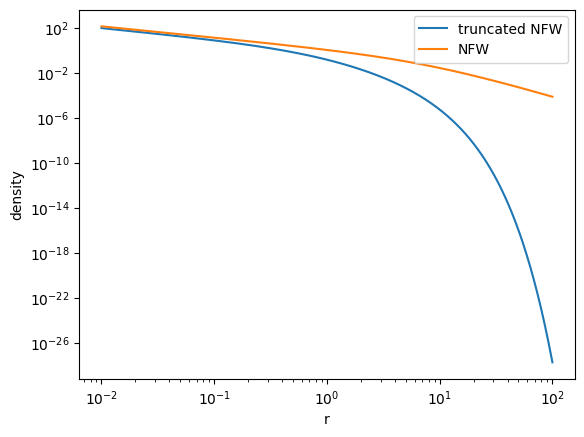

In [17]:
plt.loglog(rlist, truncNFWdens(rlist.value), label='truncated NFW')
plt.loglog(rlist, nfwpot.dens(rlist, z=0), label='NFW')
plt.xlabel('r')
plt.ylabel('density')
plt.legend()

In [18]:
mtotal = truncNFWpot.mass(rcutoff*10, z=None)

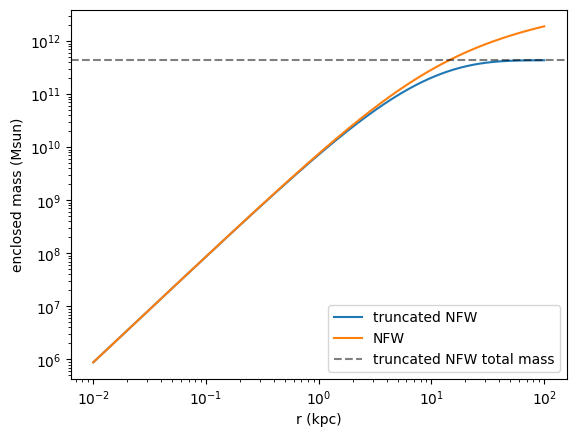

In [19]:
plt.loglog(rlist, [truncNFWpot.mass(r, z=None) for r in rlist], label='truncated NFW')
plt.loglog(rlist, [nfwpot.mass(r, z=None) for r in rlist], label='NFW')
plt.axhline(mtotal, color='k', ls='--', label='truncated NFW total mass', alpha=0.5)
plt.xlabel('r (kpc)')
plt.ylabel('enclosed mass (Msun)')
plt.legend()

/tmp/ipykernel_2752212/1279322492.py:9: RuntimeWarning: overflow encountered in exp
  np.exp(r/rcutoff)#np.cosh(r/rcutoff)



Text(0, 0.5, 'potential')

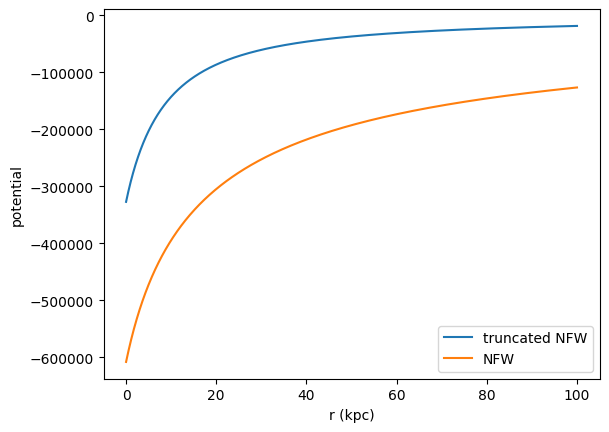

In [20]:
plt.plot(rlist, [truncNFWpot(r, z=0) for r in rlist], label='truncated NFW')
plt.plot(rlist, nfwpot(rlist, z=0), label='NFW')
plt.legend()
plt.xlabel('r (kpc)')
plt.ylabel('potential')
#plt.xscale('log')

In [21]:
from ezfalcon.tools import galpysampler

In [22]:
from galpy.potential import interpSphericalPotential

interpTruncNFW = interpSphericalPotential(truncNFWpot, rgrid = np.logspace(-2, 2, 1000))

/tmp/ipykernel_2752212/1279322492.py:9: RuntimeWarning: overflow encountered in exp
  np.exp(r/rcutoff)#np.cosh(r/rcutoff)



In [23]:
def trunc_ddensdr(self, r, t=0.):
    truncdr = lambda r: - (1 / rcutoff) * np.exp(-r / rcutoff)
    return (truncNFWdens(r) * nfwpot._ddensdr(r, 0.) +
            truncdr(r) * nfwpot._dens(r, 0.)
            )
import types
interpTruncNFW._ddensdr = types.MethodType(trunc_ddensdr, interpTruncNFW)

def trunc_d2densdr2(self, r, t=0.):
    truncdr = lambda r: - (1 / rcutoff) * np.exp(-r / rcutoff)
    truncdr2 = lambda r: (1 / rcutoff)**2 * np.exp(-r / rcutoff)
    return (truncdr(r) * nfwpot._d2densdr2(r, 0.) +
            truncdr2(r) * nfwpot._ddensdr(r, 0.)
            )
import types
interpTruncNFW._d2densdr2 = types.MethodType(trunc_d2densdr2,interpTruncNFW)

In [24]:
def trunc_ddensdr(self, r, t=0.):
    truncdr = lambda r: - (1 / rcutoff) * np.exp(-r / rcutoff)
    return (truncNFWdens(r) * nfwpot._ddensdr(r, 0.) +
            truncdr(r) * nfwpot._dens(r, 0.)
            )
import types
truncNFWpot._ddensdr = types.MethodType(trunc_ddensdr, truncNFWpot)

def trunc_d2densdr2(self, r, t=0.):
    truncdr = lambda r: - (1 / rcutoff) * np.exp(-r / rcutoff)
    truncdr2 = lambda r: (1 / rcutoff)**2 * np.exp(-r / rcutoff)
    return (truncdr(r) * nfwpot._d2densdr2(r, 0.) +
            truncdr2(r) * nfwpot._ddensdr(r, 0.)
            )
import types
truncNFWpot._d2densdr2 = types.MethodType(trunc_d2densdr2, truncNFWpot)

galpysampler(interpTruncNFW, n=1000, m_total = mtotal)

In [25]:
from galpy.df import eddingtondf

In [26]:
# interpdf = eddingtondf(pot=interpTruncNFW)
# o_samp_inter = interpdf.sample(n=10)

truedf = eddingtondf(pot=truncNFWpot)
o_samp_true = truedf.sample(n=10)

/tmp/ipykernel_2752212/1279322492.py:9: RuntimeWarning: overflow encountered in exp
  np.exp(r/rcutoff)#np.cosh(r/rcutoff)

/tmp/ipykernel_2752212/1279322492.py:7: RuntimeWarning: overflow encountered in scalar multiply
  (r / a) *



/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/lib/python3.12/site-packages/galpy/df/eddingtondf.py:181: RuntimeWarning: invalid value encountered in scalar divide
  (Fr * d2nudr2(r) + dnudr(r) * evaluateR2derivs(pot, r, 0, use_physical=False))

/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/lib/python3.12/site-packages/galpy/df/eddingtondf.py:152: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integrate.quad(

/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/lib/python3.12/site-packages/galpy/df/eddingtondf.py:152: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and cal

ValueError: x must be increasing if s > 0

In [ ]:
plt.scatter(o_samp_true.x(), o_samp_true.y(), s=1, alpha=0.5)

In [ ]:
pos, vel, mass = galpysampler(pot = truncNFWpot, n = 1000, m_total=mtotal)

## Custom `SphericalPotential` subclass

Subclass `SphericalPotential` directly with analytic density derivatives, and a one-time spline of the mass profile and outer potential integral. This avoids both the per-call `quad` of `AnySphericalPotential` and the spline-of-spline density derivatives produced by `interpSphericalPotential`.

In [ ]:
from galpy.potential.SphericalPotential import SphericalPotential
from scipy import integrate, interpolate


class TruncatedNFWPotential(SphericalPotential):
    """Exponentially-truncated NFW potential.

    rho(r) = amp / [ (r/a) * (1 + r/a)**2 * exp(r/rc) ]

    Analytic density and density derivatives; mass profile and outer
    potential integral are precomputed once on a log-r grid and splined.
    """

    def __init__(self, amp=1.0, a=1.0, rc=2.0,
                 rgrid=np.logspace(-4, 3, 4001),
                 ro=None, vo=None):
        SphericalPotential.__init__(self, amp=amp, ro=ro, vo=vo)
        self._a = a
        self._rc = rc
        self._scale = a
        self._rgrid = rgrid

        # Mass profile M(<r) on the grid (with amp factored out -- multiplied by
        # SphericalPotential's amp wrapper).
        integrand = lambda s: 4.0 * np.pi * s**2 * self._dens_unit(s)
        m_grid = np.empty_like(rgrid)
        m_grid[0] = integrate.quad(integrand, 0.0, rgrid[0])[0]
        for i in range(1, len(rgrid)):
            m_grid[i] = m_grid[i - 1] + integrate.quad(
                integrand, rgrid[i - 1], rgrid[i]
            )[0]
        self._mtot = m_grid[-1] + integrate.quad(integrand, rgrid[-1], np.inf)[0]
        self._m_spline = interpolate.CubicSpline(
            np.log(rgrid), m_grid, extrapolate=False
        )

        # Outer integral I(r) = \int_r^infty rho(s) s ds, for the potential.
        outer_integrand = lambda s: self._dens_unit(s) * s
        i_grid = np.empty_like(rgrid)
        i_grid[-1] = integrate.quad(outer_integrand, rgrid[-1], np.inf)[0]
        for i in range(len(rgrid) - 2, -1, -1):
            i_grid[i] = i_grid[i + 1] + integrate.quad(
                outer_integrand, rgrid[i], rgrid[i + 1]
            )[0]
        self._i_spline = interpolate.CubicSpline(
            np.log(rgrid), i_grid, extrapolate=False
        )

    # rho with amp = 1; SphericalPotential multiplies by self._amp externally.
    def _dens_unit(self, r):
        x = r / self._a
        return 1.0 / (x * (1.0 + x) ** 2 * np.exp(r / self._rc))

    def _mass_enclosed(self, r):
        return self._m_spline(np.log(r))

    # --- SphericalPotential interface ---

    def _revaluate(self, r, t=0.0):
        # Phi(r) = -G [ M(<r)/r + 4 pi \int_r^infty rho(s) s ds ]
        return -(self._mass_enclosed(r) / r
                 + 4.0 * np.pi * self._i_spline(np.log(r)))

    def _rforce(self, r, t=0.0):
        return -self._mass_enclosed(r) / r**2

    def _r2deriv(self, r, t=0.0):
        # d2 Phi / dr2 = 4 pi rho - 2 M/r^3
        return 4.0 * np.pi * self._dens_unit(r) - 2.0 * self._mass_enclosed(r) / r**3

    def _dens(self, r, t=0.0):
        return self._dens_unit(r)

    def _ddensdr(self, r, t=0.0):
        rho = self._dens_unit(r)
        g = 1.0 / r + 2.0 / (self._a + r) + 1.0 / self._rc
        return -rho * g

    def _d2densdr2(self, r, t=0.0):
        rho = self._dens_unit(r)
        g = 1.0 / r + 2.0 / (self._a + r) + 1.0 / self._rc
        gprime = -1.0 / r**2 - 2.0 / (self._a + r) ** 2
        return rho * (g * g - gprime)


In [ ]:
import time

amp_phys = rho0 * 4 * np.pi * a**3  # match the AnySphericalPotential normalization
truncNFWpot_fast = TruncatedNFWPotential(amp=amp_phys, a=a, rc=rcutoff)

# Sanity-check density and derivatives match the AnySphericalPotential result.
rtest = np.array([0.1, 1.0, 5.0, 20.0])
print("rho(r):  ", truncNFWpot_fast.dens(rtest, z=0))
print("ref:     ", [truncNFWpot.dens(r, z=0) for r in rtest])
print("Phi(r):  ", [truncNFWpot_fast(r, z=0) for r in rtest])
print("ref:     ", [truncNFWpot(r, z=0) for r in rtest])
print("M(<r):   ", [truncNFWpot_fast._mass_enclosed(r) * amp_phys for r in rtest])
print("ref:     ", [truncNFWpot.mass(r, z=None) for r in rtest])

In [ ]:
t0 = time.time()
fastdf = eddingtondf(pot=truncNFWpot_fast)
print(f"eddingtondf init: {time.time() - t0:.2f}s")

t0 = time.time()
o_samp_fast = fastdf.sample(n=1000)
print(f"sample(n=1000):   {time.time() - t0:.2f}s")

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(o_samp_fast.x(), o_samp_fast.y(), s=1, alpha=0.4)
ax[0].set_xlabel('x'); ax[0].set_ylabel('y'); ax[0].set_aspect('equal')

r_samp = np.sqrt(o_samp_fast.x()**2 + o_samp_fast.y()**2 + o_samp_fast.z()**2)
ax[1].hist(np.log10(r_samp.value), bins=40, density=True, alpha=0.6, label='samples')
rgrid = np.logspace(-2, 2, 200)
mtrue = np.array([truncNFWpot_fast._mass_enclosed(r) * amp_phys for r in rgrid])
pdf = np.gradient(mtrue, rgrid) * rgrid * np.log(10) / mtrue[-1]
ax[1].plot(np.log10(rgrid), pdf, 'k-', label='analytic dM/d log10 r')
ax[1].set_xlabel('log10 r'); ax[1].legend()